# TCN + BiGRU + XGBoost -- CMAPSS Engine-Level Sequence Labeling

**Pipeline:**
1. Engine-level padded sequence construction (one sequence per engine; no sliding windows)
2. **TCN + BiGRU sequence-labeling encoder** with per-cycle logits
3. **Hybrid loss**: masked focal sequence-labeling loss + masked MSE reconstruction
4. **Feature fusion**: per-cycle deep embedding + prefix trend features
5. Leakage-free GridSearchCV on **train only** with engine groups; validation is reserved for threshold and smoothing selection
6. **Business-aware timestep threshold** selected on validation only
7. **Decision mode** (timestep vs engine smoothing) selected on validation only
8. **Dual test reporting**: `last` protocol for CMAPSS literature comparison and `sequence` protocol for full engine-timeline evaluation

All four CMAPSS datasets (FD001-FD004) are supported via `CFG['dataset']`.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
import os, warnings, random
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, fbeta_score, recall_score, roc_auc_score,
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score, roc_curve,
    make_scorer,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
try:
    from sklearn.model_selection import StratifiedGroupKFold
except ImportError:
    StratifiedGroupKFold = None

import xgboost as xgb
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)


Device: cuda


## Configuration

In [3]:
BASE = '/content/drive/MyDrive/data'

CFG = {
    # --- Data ---
    'dataset'          : 'FD001',   # FD001 | FD002 | FD003 | FD004
    'rul_threshold'    : 30,
    'min_engine_cycles': 1,
    'val_engine_frac'  : 0.15,

    # --- TCN ---
    'tcn_channels'     : [64, 128, 128, 64],
    'tcn_kernel'       : 3,
    'tcn_dropout'      : 0.2,

    # --- BiGRU ---
    'gru_hidden'       : 128,
    'gru_layers'       : 2,
    'gru_dropout'      : 0.3,

    # --- Embedding ---
    'embed_dim'        : 128,

    # --- Training ---
    'epochs'           : 60,
    'batch_size'       : 16,
    'lr'               : 1e-3,
    'weight_decay'     : 1e-4,
    'patience'         : 12,
    'focal_gamma'      : 2.5,
    'recon_weight'     : 0.1,        # hybrid loss alpha for masked MSE reconstruction

    # --- Recall-boost ---
    'pos_weight_boost' : 2.0,
    'recall_beta'      : 2.0,

    # --- Test-time evaluation ---
    # Both protocols are always built and reported.
    # 'last'    : last valid timestep per test engine; CMAPSS literature-comparable protocol
    # 'sequence': every valid timestep from each test engine; full-timeline protocol
    'test_protocols'        : ['last', 'sequence'],
    'primary_test_protocol' : 'last',
    'use_engine_smoothing'  : True,
    'use_semantic_features' : True,

    # --- Business-aware threshold ---
    'min_precision'    : 0.70,
    'f1_tolerance'     : 0.005,

    # --- Engine-smoothing search grid ---
    'ma_k_grid'        : [3, 5, 7],
    'persist_grid'     : [(2, 1), (3, 1), (3, 2), (4, 2)],

    # --- XGBoost base defaults ---
    'xgb_rounds'       : 800,
    'xgb_lr'           : 0.03,
    'xgb_depth'        : 6,
    'xgb_subsample'    : 0.8,
    'xgb_colsample'    : 0.8,
    'xgb_min_child'    : 3,
    'xgb_alpha'        : 0.1,
    'xgb_lambda'       : 1.0,
    'xgb_es_rounds'    : 40,

    # --- GridSearchCV ---
    'grid_cv_folds'    : 3,
    'grid_n_jobs'      : -1,

    # --- Optional article experiments ---
    'ablation_fd'      : 'FD001',
    'ablation_enabled' : False,
    'seed_list'        : [42, 123, 2024],
    'recon_weight_grid': [0.0, 0.1, 0.3, 0.5, 1.0],
}


## Data Loading and Preprocessing

In [4]:
COLUMNS = (
    ['unit_number', 'time_in_cycles']
    + [f'op_{i}' for i in range(1, 4)]
    + [f's{i}'  for i in range(1, 22)]
)

# Sensors with near-zero variance (uninformative)
DROP_SENSORS = ['s1', 's5', 's6', 's10', 's16', 's18', 's19']


def load_raw(fd):
    train = pd.read_csv(f'{BASE}/train_{fd}.txt', sep=r'\s+', header=None, names=COLUMNS)
    test  = pd.read_csv(f'{BASE}/test_{fd}.txt',  sep=r'\s+', header=None, names=COLUMNS)
    rul   = pd.read_csv(f'{BASE}/RUL_{fd}.txt',   header=None, names=['RUL'])
    return train, test, rul


def add_train_rul(df):
    max_c = df.groupby('unit_number')['time_in_cycles'].max()
    df = df.join(max_c.rename('max_c'), on='unit_number')
    df['RUL'] = df['max_c'] - df['time_in_cycles']
    return df.drop('max_c', axis=1)


def add_test_rul(test_df, rul_df):
    """Per-step RUL for test rows, computed from trailing RUL table."""
    test_df = test_df.copy()
    max_c = test_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    max_c.columns = ['unit_number', 'max_c']
    rul = rul_df.copy()
    rul['unit_number'] = np.arange(1, len(rul) + 1)
    max_c = max_c.merge(rul, on='unit_number', how='left')
    max_c['final_cycle'] = max_c['max_c'] + max_c['RUL']
    test_df = test_df.merge(max_c[['unit_number', 'final_cycle']],
                            on='unit_number', how='left')
    test_df['RUL'] = test_df['final_cycle'] - test_df['time_in_cycles']
    return test_df.drop('final_cycle', axis=1)


def get_features(df):
    drop = ['unit_number', 'time_in_cycles', 'RUL'] + DROP_SENSORS
    return [c for c in df.columns if c not in drop]


def split_train_val(train_df, val_frac, seed=42):
    units = train_df['unit_number'].unique()
    rng   = np.random.RandomState(seed)
    val_units = rng.choice(units, size=int(len(units) * val_frac), replace=False)
    val_mask  = train_df['unit_number'].isin(val_units)
    return train_df[~val_mask].copy(), train_df[val_mask].copy()


def make_engine_sequences(df, feat_cols, threshold, min_cycles=1):
    """One padded sequence per engine with a binary label at every valid cycle."""
    seqs, labs, engines, cycles, lengths = [], [], [], [], []
    for uid, group in df.groupby('unit_number'):
        group = group.sort_values('time_in_cycles')
        if len(group) < min_cycles:
            continue
        arr = group[feat_cols].values.astype(np.float32)
        y = (group['RUL'].values < threshold).astype(np.int64)
        c = group['time_in_cycles'].values.astype(np.int64)
        seqs.append(arr)
        labs.append(y)
        engines.append(np.full(len(group), int(uid), dtype=np.int64))
        cycles.append(c)
        lengths.append(len(group))

    if not seqs:
        raise ValueError('No engine sequences were created. Check min_engine_cycles and input data.')

    n_eng = len(seqs)
    max_len = max(lengths)
    n_feat = len(feat_cols)

    X = np.zeros((n_eng, max_len, n_feat), dtype=np.float32)
    y = np.zeros((n_eng, max_len), dtype=np.int64)
    mask = np.zeros((n_eng, max_len), dtype=bool)
    eng_grid = np.full((n_eng, max_len), -1, dtype=np.int64)
    cyc_grid = np.full((n_eng, max_len), -1, dtype=np.int64)

    for i, (arr, lab, eng, cyc) in enumerate(zip(seqs, labs, engines, cycles)):
        L = len(arr)
        X[i, :L] = arr
        y[i, :L] = lab
        mask[i, :L] = True
        eng_grid[i, :L] = eng
        cyc_grid[i, :L] = cyc

    return X, y, mask, np.array(lengths, dtype=np.int64), eng_grid, cyc_grid


def flatten_valid(values, mask):
    """Flatten valid padded timesteps in engine order."""
    return values[mask.astype(bool)]


def last_valid_flat_indices(mask):
    """Indices of each engine's final valid timestep after row-major valid flattening."""
    lengths = mask.sum(axis=1).astype(np.int64)
    offsets = np.concatenate([[0], np.cumsum(lengths[:-1])])
    return offsets + lengths - 1


# Load
FD = CFG['dataset']
train_raw, test_raw, rul_raw = load_raw(FD)
train_raw = add_train_rul(train_raw)
test_raw  = add_test_rul(test_raw, rul_raw)

# Engine-level split (no leakage)
tr_df, val_df = split_train_val(train_raw, CFG['val_engine_frac'])
feat_cols = get_features(tr_df)
print(f'Features ({len(feat_cols)}): {feat_cols}')

# Standardise (fit on train only)
scaler = StandardScaler()
tr_df[feat_cols]    = scaler.fit_transform(tr_df[feat_cols])
val_df[feat_cols]   = scaler.transform(val_df[feat_cols])
test_raw[feat_cols] = scaler.transform(test_raw[feat_cols])

# Build engine-level sequence-labeling tensors.
TH = CFG['rul_threshold']
MIN_C = CFG.get('min_engine_cycles', 1)
X_tr,  y_tr_seq,  mask_tr,  len_tr,  eng_tr_grid,  cyc_tr_grid  = make_engine_sequences(tr_df, feat_cols, TH, MIN_C)
X_val, y_val_seq, mask_val, len_val, eng_val_grid, cyc_val_grid = make_engine_sequences(val_df, feat_cols, TH, MIN_C)
X_te,  y_te_seq_full, mask_te, len_te, eng_te_grid, cyc_te_grid = make_engine_sequences(test_raw, feat_cols, TH, MIN_C)

# Flat valid timesteps for XGBoost and metrics.
y_tr = flatten_valid(y_tr_seq, mask_tr)
y_val = flatten_valid(y_val_seq, mask_val)
y_te_sequence = flatten_valid(y_te_seq_full, mask_te)

eng_tr = flatten_valid(eng_tr_grid, mask_tr)
eng_val = flatten_valid(eng_val_grid, mask_val)
eng_te_sequence = flatten_valid(eng_te_grid, mask_te)

cyc_te_sequence = flatten_valid(cyc_te_grid, mask_te)
last_te_idx = last_valid_flat_indices(mask_te)
y_te_last = y_te_sequence[last_te_idx]
eng_te_last = eng_te_sequence[last_te_idx]
cyc_te_last = cyc_te_sequence[last_te_idx]

TEST_LABELS = {
    'last': {
        'y': y_te_last,
        'engine': eng_te_last,
        'cycle': cyc_te_last,
        'description': 'last valid timestep per test engine',
    },
    'sequence': {
        'y': y_te_sequence,
        'engine': eng_te_sequence,
        'cycle': cyc_te_sequence,
        'description': 'all valid timesteps from engine-level sequences',
    },
}

print(f'Train sequences : {X_tr.shape} | valid timesteps: {len(y_tr)} | pos ratio: {y_tr.mean():.3f}')
print(f'Val sequences   : {X_val.shape} | valid timesteps: {len(y_val)} | pos ratio: {y_val.mean():.3f}')
for protocol, data in TEST_LABELS.items():
    print(f'Test {protocol:<8}: N={len(data["y"]):5d} | pos ratio: {data["y"].mean():.3f} | '
          f'engines: {len(np.unique(data["engine"]))} | {data["description"]}')


Features (17): ['op_1', 'op_2', 'op_3', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Train sequences : (85, 362, 17) | valid timesteps: 17569 | pos ratio: 0.145
Val sequences   : (15, 267, 17) | valid timesteps: 3062 | pos ratio: 0.147
Test last    : N=  100 | pos ratio: 0.250 | engines: 100 | last valid timestep per test engine
Test sequence: N=13096 | pos ratio: 0.023 | engines: 100 | all valid timesteps from engine-level sequences


## Model: TCN + BiGRU + Attention

In [5]:
class CausalConvBlock(nn.Module):
    """Single dilated causal conv block (WeightNorm + residual)."""
    def __init__(self, in_ch, out_ch, kernel, dilation, dropout):
        super().__init__()
        pad = (kernel - 1) * dilation
        self.conv1 = nn.utils.weight_norm(
            nn.Conv1d(in_ch, out_ch, kernel, padding=pad, dilation=dilation))
        self.conv2 = nn.utils.weight_norm(
            nn.Conv1d(out_ch, out_ch, kernel, padding=pad, dilation=dilation))
        self.drop  = nn.Dropout(dropout)
        self.relu  = nn.ReLU()
        self.res   = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        out = self.relu(self.conv1(x)[:, :, :x.size(2)])
        out = self.drop(out)
        out = self.relu(self.conv2(out)[:, :, :x.size(2)])
        out = self.drop(out)
        res = x if self.res is None else self.res(x)
        return self.relu(out + res)


class TCN(nn.Module):
    """Dilated TCN -- dilation doubles each layer (2^i)."""
    def __init__(self, in_ch, channels, kernel, dropout):
        super().__init__()
        layers = []
        for i, out_ch in enumerate(channels):
            layers.append(CausalConvBlock(in_ch, out_ch, kernel,
                                          dilation=2**i, dropout=dropout))
            in_ch = out_ch
        self.net = nn.Sequential(*layers)

    def forward(self, x):           # x: (B, T, C_in)
        x = x.permute(0, 2, 1)     # -> (B, C, T)
        x = self.net(x)
        return x.permute(0, 2, 1)  # -> (B, T, C_out)


class TCNBiGRU(nn.Module):
    """TCN+BiGRU sequence labeler with two per-timestep heads:
       cls_head  : binary near-failure logit for every valid cycle
       recon_head: reconstruct input features for every valid cycle
    """
    def __init__(self, n_feat, cfg):
        super().__init__()
        self.tcn = TCN(n_feat, cfg['tcn_channels'], cfg['tcn_kernel'], cfg['tcn_dropout'])
        tcn_out  = cfg['tcn_channels'][-1]

        self.bigru = nn.GRU(
            input_size    = tcn_out,
            hidden_size   = cfg['gru_hidden'],
            num_layers    = cfg['gru_layers'],
            batch_first   = True,
            bidirectional = True,
            dropout       = cfg['gru_dropout'] if cfg['gru_layers'] > 1 else 0,
        )
        gru_out = cfg['gru_hidden'] * 2

        self.proj = nn.Sequential(
            nn.Linear(gru_out, cfg['embed_dim']),
            nn.LayerNorm(cfg['embed_dim']),
            nn.GELU(),
            nn.Dropout(0.2),
        )
        self.cls_head   = nn.Linear(cfg['embed_dim'], 1)
        self.recon_head = nn.Sequential(
            nn.Linear(cfg['embed_dim'], 64),
            nn.ReLU(),
            nn.Linear(64, n_feat),
        )

    def encode(self, x, lengths=None):
        t = self.tcn(x)
        if lengths is not None:
            lengths_cpu = lengths.detach().cpu()
            packed = nn.utils.rnn.pack_padded_sequence(
                t, lengths_cpu, batch_first=True, enforce_sorted=False)
            packed_out, _ = self.bigru(packed)
            t, _ = nn.utils.rnn.pad_packed_sequence(
                packed_out, batch_first=True, total_length=x.size(1))
        else:
            t, _ = self.bigru(t)
        return self.proj(t)

    def embed(self, x, lengths=None):
        return self.encode(x, lengths)

    def forward(self, x, lengths=None):
        z = self.embed(x, lengths)
        return self.cls_head(z).squeeze(-1), self.recon_head(z), z


n_feat = X_tr.shape[2]
model  = TCNBiGRU(n_feat, CFG).to(DEVICE)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


Trainable parameters: 731,794


## Focal Loss + Training Loop

In [6]:
class FocalLoss(nn.Module):
    """Masked focal loss (BCE-based) to handle per-timestep class imbalance."""
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets, mask=None):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets.float(), pos_weight=self.pos_weight, reduction='none')
        prob = torch.sigmoid(logits)
        pt   = torch.where(targets == 1, prob, 1 - prob)
        loss = (1 - pt) ** self.gamma * bce
        if mask is not None:
            loss = loss[mask.bool()]
        return loss.mean()


def get_loader(X, y_seq, mask, lengths, batch_size, shuffle=True):
    ds = TensorDataset(
        torch.from_numpy(X),
        torch.from_numpy(y_seq),
        torch.from_numpy(mask),
        torch.from_numpy(lengths),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, pin_memory=True)


# Boost pos_weight to push the sequence labeler toward higher recall
raw_pos_ratio = float((y_tr == 0).sum() / max((y_tr == 1).sum(), 1))
boosted_pw    = raw_pos_ratio * CFG['pos_weight_boost']
pos_w = torch.tensor([boosted_pw], dtype=torch.float32).to(DEVICE)
print(f'Focal loss pos_weight: {raw_pos_ratio:.2f} x {CFG["pos_weight_boost"]} = {boosted_pw:.2f}')

cls_criterion   = FocalLoss(gamma=CFG['focal_gamma'], pos_weight=pos_w)
recon_criterion = nn.MSELoss(reduction='none')
RECON_W         = CFG['recon_weight']

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG['lr'],
                               weight_decay=CFG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs'], eta_min=1e-5)

tr_loader  = get_loader(X_tr,  y_tr_seq,  mask_tr,  len_tr,  CFG['batch_size'], shuffle=True)
val_loader = get_loader(X_val, y_val_seq, mask_val, len_val, CFG['batch_size'], shuffle=False)

BETA = CFG['recall_beta']

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_valid, preds, trues = 0.0, 0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb, mb, lb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            mb = mb.to(DEVICE).bool()
            lb = lb.to(DEVICE)
            logits, recon, _ = model(xb, lb)
            cls_loss = cls_criterion(logits, yb, mb)
            recon_step = recon_criterion(recon, xb).mean(dim=2)
            recon_loss = recon_step[mb].mean()
            loss = cls_loss + RECON_W * recon_loss
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            valid_count = int(mb.sum().item())
            total_loss += loss.item() * valid_count
            total_valid += valid_count
            preds.extend(torch.sigmoid(logits)[mb].detach().cpu().numpy())
            trues.extend(yb[mb].detach().cpu().numpy())
    preds, trues = np.array(preds), np.array(trues)
    fb  = fbeta_score(trues, (preds > 0.5).astype(int), beta=BETA, zero_division=0)
    auc = roc_auc_score(trues, preds) if len(np.unique(trues)) > 1 else 0.5
    return total_loss / max(total_valid, 1), fb, auc


print(f'Hybrid sequence-labeling training (focal + {RECON_W}*masked recon, F{BETA:.0f} early-stop)...')
best_val_fb, best_state, no_improve = -1.0, None, 0
history = {'tr_loss':[], 'val_loss':[], 'tr_f1':[], 'val_f1':[], 'val_auc':[]}

for ep in range(1, CFG['epochs'] + 1):
    tr_loss,  tr_fb,  _       = run_epoch(tr_loader,  train=True)
    val_loss, val_fb, val_auc = run_epoch(val_loader, train=False)
    scheduler.step()
    history['tr_loss'].append(tr_loss);   history['val_loss'].append(val_loss)
    history['tr_f1'].append(tr_fb);       history['val_f1'].append(val_fb)
    history['val_auc'].append(val_auc)
    if val_fb > best_val_fb:
        best_val_fb = val_fb
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve  = 0
    else:
        no_improve += 1
    if ep % 5 == 0 or ep == 1:
        print(f'Epoch {ep:3d} | tr_loss={tr_loss:.4f} tr_F{BETA:.0f}={tr_fb:.4f} | '
              f'val_loss={val_loss:.4f} val_F{BETA:.0f}={val_fb:.4f} val_auc={val_auc:.4f}')
    if no_improve >= CFG['patience']:
        print(f'Early stopping at epoch {ep}')
        break

model.load_state_dict(best_state)
print(f'\nBest val F{BETA:.0f}: {best_val_fb:.4f}')


Focal loss pos_weight: 5.89 x 2.0 = 11.78
Hybrid sequence-labeling training (focal + 0.1*masked recon, F2 early-stop)...
Epoch   1 | tr_loss=0.5103 tr_F2=0.5269 | val_loss=0.1699 val_F2=0.8371 val_auc=0.9898
Epoch   5 | tr_loss=0.1048 tr_F2=0.9012 | val_loss=0.1008 val_F2=0.9465 val_auc=0.9960
Epoch  10 | tr_loss=0.0682 tr_F2=0.9591 | val_loss=0.0698 val_F2=0.9383 val_auc=0.9990
Epoch  15 | tr_loss=0.0552 tr_F2=0.9766 | val_loss=0.0527 val_F2=0.9714 val_auc=0.9994
Epoch  20 | tr_loss=0.0506 tr_F2=0.9746 | val_loss=0.0524 val_F2=0.9591 val_auc=0.9995
Epoch  25 | tr_loss=0.0444 tr_F2=0.9805 | val_loss=0.0425 val_F2=0.9833 val_auc=0.9997
Epoch  30 | tr_loss=0.0408 tr_F2=0.9848 | val_loss=0.0386 val_F2=0.9851 val_auc=0.9998
Epoch  35 | tr_loss=0.0396 tr_F2=0.9866 | val_loss=0.0375 val_F2=0.9864 val_auc=0.9999
Epoch  40 | tr_loss=0.0395 tr_F2=0.9878 | val_loss=0.0366 val_F2=0.9886 val_auc=0.9999
Epoch  45 | tr_loss=0.0373 tr_F2=0.9897 | val_loss=0.0370 val_F2=0.9881 val_auc=0.9998
Early sto

## Training Curves

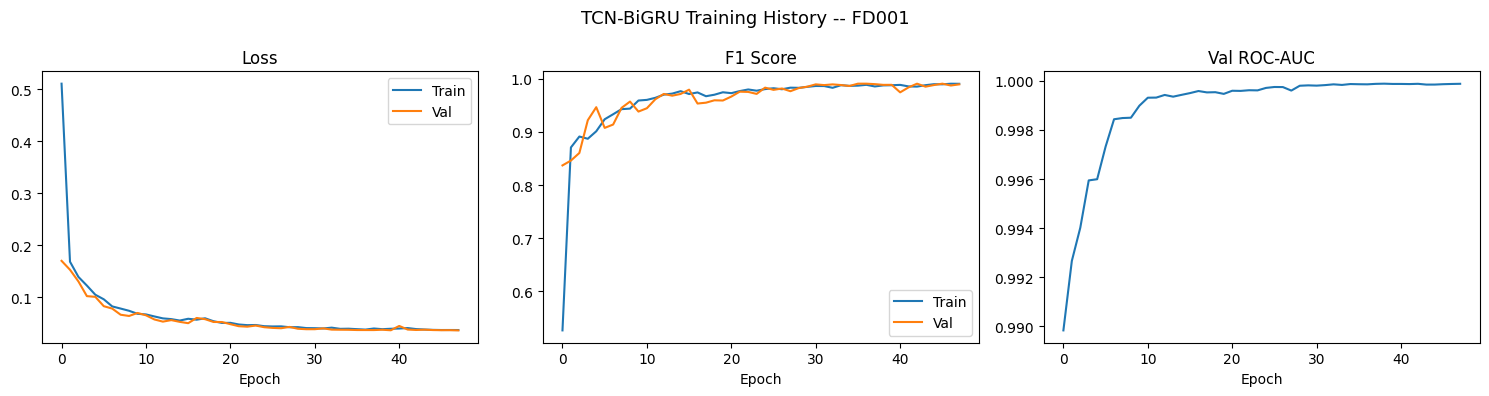

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['tr_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['tr_f1'], label='Train')
axes[1].plot(history['val_f1'], label='Val')
axes[1].set_title('F1 Score'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history['val_auc'])
axes[2].set_title('Val ROC-AUC'); axes[2].set_xlabel('Epoch')

plt.suptitle(f'TCN-BiGRU Training History -- {FD}', fontsize=13)
plt.tight_layout()
plt.show()

## Per-Timestep Embedding Extraction (for XGBoost)


In [8]:
@torch.no_grad()
def extract_sequence_embeddings(X_np, lengths_np, mask_np, batch_size=64):
    """Convert padded engine sequences to per-valid-timestep embeddings."""
    model.eval()
    seq_parts = []
    ds = TensorDataset(torch.from_numpy(X_np), torch.from_numpy(lengths_np))
    for xb, lb in DataLoader(ds, batch_size=batch_size, shuffle=False):
        z = model.embed(xb.to(DEVICE), lb.to(DEVICE)).detach().cpu().numpy()
        seq_parts.append(z)
    emb_seq = np.concatenate(seq_parts, axis=0)
    emb_flat = emb_seq[mask_np.astype(bool)]
    return emb_seq, emb_flat


def _prefix_stats(prefix):
    n, C = prefix.shape
    x_mean  = prefix.mean(axis=0)
    x_std   = prefix.std(axis=0)
    x_min   = prefix.min(axis=0)
    x_max   = prefix.max(axis=0)
    x_rng   = x_max - x_min
    x_drift = prefix[-1] - prefix[0]
    energy  = (prefix ** 2).sum(axis=0) / max(n, 1)

    if n > 1:
        t = np.arange(n, dtype=np.float32)
        t_mean = t.mean()
        denom = max(float(np.sum((t - t_mean) ** 2)), 1e-9)
        slope = ((t[:, None] - t_mean) * (prefix - x_mean[None, :])).sum(axis=0) / denom
        diff = np.diff(prefix, axis=0)
        diff_abs_mean = np.abs(diff).mean(axis=0)
        diff_std = diff.std(axis=0)
        pos_frac = (diff > 0).mean(axis=0)
        neg_frac = (diff < 0).mean(axis=0)
    else:
        slope = np.zeros(C, dtype=np.float32)
        diff_abs_mean = np.zeros(C, dtype=np.float32)
        diff_std = np.zeros(C, dtype=np.float32)
        pos_frac = np.zeros(C, dtype=np.float32)
        neg_frac = np.zeros(C, dtype=np.float32)

    feats = np.stack([x_mean, x_std, x_min, x_max, x_rng, x_drift,
                      slope, diff_abs_mean, diff_std, energy,
                      pos_frac, neg_frac], axis=1)
    return feats.reshape(C * 12).astype(np.float32)


def extract_prefix_semantic_features(X, mask):
    """12 trend statistics per channel for each valid prefix ending at each cycle."""
    rows = []
    for seq, m in zip(X, mask):
        n = int(m.sum())
        for end in range(1, n + 1):
            rows.append(_prefix_stats(seq[:end]))
    return np.vstack(rows).astype(np.float32)


def fuse_features(emb, sem=None):
    if not CFG['use_semantic_features']:
        return emb
    return np.concatenate([emb, sem], axis=1)


print('Extracting per-timestep sequence embeddings...')
emb_tr_seq, emb_tr = extract_sequence_embeddings(X_tr, len_tr, mask_tr)
emb_val_seq, emb_val = extract_sequence_embeddings(X_val, len_val, mask_val)
emb_te_seq, emb_te_sequence = extract_sequence_embeddings(X_te, len_te, mask_te)
emb_te_last = emb_te_sequence[last_te_idx]
print(f'emb_tr: {emb_tr.shape}  emb_val: {emb_val.shape}  '
      f'emb_last: {emb_te_last.shape}  emb_sequence: {emb_te_sequence.shape}')

if CFG['use_semantic_features']:
    print('Extracting prefix semantic trend features and fusing...')
    sem_tr = extract_prefix_semantic_features(X_tr, mask_tr)
    sem_val = extract_prefix_semantic_features(X_val, mask_val)
    sem_te_sequence = extract_prefix_semantic_features(X_te, mask_te)
    sem_te_last = sem_te_sequence[last_te_idx]
else:
    print('Semantic trend features disabled; using deep embeddings only.')
    sem_tr = sem_val = sem_te_sequence = sem_te_last = None

feat_tr          = fuse_features(emb_tr, sem_tr)
feat_val         = fuse_features(emb_val, sem_val)
feat_te_last     = fuse_features(emb_te_last, sem_te_last)
feat_te_sequence = fuse_features(emb_te_sequence, sem_te_sequence)

TEST_FEATURES = {
    'last': feat_te_last,
    'sequence': feat_te_sequence,
}

print(f'fused_tr: {feat_tr.shape}  fused_val: {feat_val.shape}  '
      f'fused_last: {feat_te_last.shape}  fused_sequence: {feat_te_sequence.shape}')


Extracting per-timestep sequence embeddings...
emb_tr: (17569, 128)  emb_val: (3062, 128)  emb_last: (100, 128)  emb_sequence: (13096, 128)
Extracting prefix semantic trend features and fusing...
fused_tr: (17569, 332)  fused_val: (3062, 332)  fused_last: (100, 332)  fused_sequence: (13096, 332)


## XGBoost Hyperparameter Search (GridSearchCV, engine-grouped and leakage-free)

Grid search over key XGBoost parameters using stratified engine-group k-fold CV scored on F-beta (β=2). **Trained on TRAIN ONLY** -- validation set is reserved for threshold + engine-smoothing selection to avoid leakage.


In [9]:
# GridSearchCV on TRAIN ONLY (no val leakage). Val is reserved for threshold + engine smoothing.
scale_pos     = float((y_tr == 0).sum() / max((y_tr == 1).sum(), 1))
scale_pos_bst = scale_pos * CFG['pos_weight_boost']
BETA          = CFG['recall_beta']

# F-beta scorer: beta>1 weights recall more than precision
f_beta_scorer = make_scorer(fbeta_score, beta=BETA, zero_division=0)

# Parameter grid (slightly trimmed for runtime; still covers the important axes)
param_grid = {
    'max_depth'        : [4, 6, 8],
    'learning_rate'    : [0.03, 0.05, 0.1],
    'min_child_weight' : [1, 3, 5],
    'subsample'        : [0.8, 1.0],
    'colsample_bytree' : [0.8, 1.0],
    'reg_alpha'        : [0.0, 0.1],
    'reg_lambda'       : [1.0, 2.0],
}

xgb_base = XGBClassifier(
    objective        = 'binary:logistic',
    n_estimators     = 400,
    scale_pos_weight = scale_pos_bst,
    tree_method      = 'hist',
    eval_metric      = 'logloss',
    random_state     = 42,
    verbosity        = 0,
)

if StratifiedGroupKFold is not None and len(np.unique(eng_tr)) >= CFG['grid_cv_folds']:
    cv_strategy = StratifiedGroupKFold(
        n_splits=CFG['grid_cv_folds'], shuffle=True, random_state=42)
    fit_kwargs = {'groups': eng_tr}
    cv_name = 'StratifiedGroupKFold by engine'
else:
    cv_strategy = StratifiedKFold(
        n_splits=CFG['grid_cv_folds'], shuffle=True, random_state=42)
    fit_kwargs = {}
    cv_name = 'StratifiedKFold'

grid_search = GridSearchCV(
    estimator  = xgb_base,
    param_grid = param_grid,
    scoring    = f_beta_scorer,
    cv         = cv_strategy,
    n_jobs     = CFG['grid_n_jobs'],
    verbose    = 1,
    refit      = True,
)

print(f'GridSearchCV on TRAIN ONLY ({CFG["grid_cv_folds"]}-fold {cv_name}, scoring=F{BETA:.0f}, '
      f'scale_pos_weight={scale_pos_bst:.2f}, timestep samples={len(y_tr)})...')
grid_search.fit(feat_tr, y_tr, **fit_kwargs)

best_params = grid_search.best_params_
best_cv_fb  = grid_search.best_score_

print('\n' + '=' * 58)
print(f'  Best CV F{BETA:.0f}  : {best_cv_fb:.4f}')
print(f'  Best parameters:')
for k, v in best_params.items():
    print(f'    {k:<22}: {v}')
print('=' * 58)

cv_df = pd.DataFrame(grid_search.cv_results_)
top10 = (
    cv_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score').head(10).reset_index(drop=True)
)
top10.index += 1
top10.columns = ['Parameters', f'Mean F{BETA:.0f}', f'Std F{BETA:.0f}', 'Rank']
top10.iloc[:, 1] = top10.iloc[:, 1].round(4)
top10.iloc[:, 2] = top10.iloc[:, 2].round(4)
print(f'\nTop-10 configurations:')
print(top10.to_string())


GridSearchCV on TRAIN ONLY (3-fold StratifiedGroupKFold by engine, scoring=F2, scale_pos_weight=11.78, timestep samples=17569)...
Fitting 3 folds for each of 432 candidates, totalling 1296 fits

  Best CV F2  : 0.9923
  Best parameters:
    colsample_bytree      : 1.0
    learning_rate         : 0.03
    max_depth             : 8
    min_child_weight      : 5
    reg_alpha             : 0.0
    reg_lambda            : 2.0
    subsample             : 1.0

Top-10 configurations:
                                                                                                                                        Parameters  Mean F2  Std F2  Rank
1   {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 8, 'min_child_weight': 5, 'reg_alpha': 0.0, 'reg_lambda': 2.0, 'subsample': 1.0}   0.9923  0.0017     1
2   {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 6, 'min_child_weight': 5, 'reg_alpha': 0.0, 'reg_lambda': 2.0, 'subsample': 1.0}   0.9922  0.0016     2
3   {'co

## XGBoost Final Training (Best Hyperparameters)

In [10]:
# Final XGBoost: train on TRAIN ONLY (fused per-timestep features), use VAL as eval for early stopping.
# Both test protocol DMatrices are built here; neither is used for tuning.
dtrain = xgb.DMatrix(feat_tr,  label=y_tr)
dval   = xgb.DMatrix(feat_val, label=y_val)
dtest_last = xgb.DMatrix(feat_te_last,     label=y_te_last)
dtest_sequence = xgb.DMatrix(feat_te_sequence, label=y_te_sequence)

DTEST = {
    'last': dtest_last,
    'sequence': dtest_sequence,
}

xgb_params = {
    'objective'        : 'binary:logistic',
    'eval_metric'      : ['logloss', 'auc'],
    'eta'              : best_params.get('learning_rate',    CFG['xgb_lr']),
    'max_depth'        : best_params.get('max_depth',        CFG['xgb_depth']),
    'subsample'        : best_params.get('subsample',        CFG['xgb_subsample']),
    'colsample_bytree' : best_params.get('colsample_bytree', CFG['xgb_colsample']),
    'min_child_weight' : best_params.get('min_child_weight', CFG['xgb_min_child']),
    'reg_alpha'        : best_params.get('reg_alpha',        CFG['xgb_alpha']),
    'reg_lambda'       : best_params.get('reg_lambda',       CFG['xgb_lambda']),
    'scale_pos_weight' : scale_pos_bst,
    'tree_method'      : 'hist',
    'seed'             : 42,
}

evals_result = {}
xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round       = CFG['xgb_rounds'],
    evals                 = [(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds = CFG['xgb_es_rounds'],
    evals_result          = evals_result,
    verbose_eval          = 50,
)
print(f'\nBest boosting round: {xgb_model.best_iteration}')


[0]	train-logloss:0.93320	train-auc:0.99919	val-logloss:0.93215	val-auc:0.99804
[50]	train-logloss:0.14539	train-auc:0.99986	val-logloss:0.14942	val-auc:0.99859
[59]	train-logloss:0.11016	train-auc:0.99992	val-logloss:0.11496	val-auc:0.99858

Best boosting round: 19


## Threshold + Decision-Mode Selection (Validation Only)

Two decision modes are searched on validation:

1. **Timestep-level threshold**: direct per-cycle classification from the engine sequence.
2. **Engine-level smoothing**: joint search over threshold, moving-average span, and persistence rule per engine.

The selected mode is frozen from validation and then applied to test. Test metrics are never used to choose between timestep and engine decisions.


In [11]:
from sklearn.metrics import precision_recall_fscore_support

# ===== Timestep-level threshold + engine-level smoothing helpers =====

def specificity_from_preds(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp + 1e-9)


def metric_dict(y_true, y_score, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0)
    return {
        'Precision': float(p),
        'Recall': float(r),
        'F1': float(f1),
        'Specificity': float(specificity_from_preds(y_true, y_pred)),
        'AUC': float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else float('nan'),
        'Avg Prec': float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else float('nan'),
    }


def evaluate_threshold(y_true, y_score, threshold):
    y_hat = (y_score >= threshold).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_hat, average='binary', zero_division=0)
    return p, r, f1, y_hat


def moving_average(x, k=5):
    return pd.Series(x).rolling(window=k, min_periods=1).mean().values


def persistence_decision(probs, threshold, window, min_count):
    raw = (probs >= threshold).astype(int)
    out = np.zeros_like(raw)
    for i in range(len(raw)):
        start = max(0, i - window + 1)
        if raw[start:i+1].sum() >= min_count:
            out[i] = 1
    return out


def evaluate_engine_smoothed(y_true, probs, engine_ids, threshold, ma_k, persist_w, min_count):
    final = np.zeros_like(y_true)
    for eng in np.unique(engine_ids):
        idx = np.where(engine_ids == eng)[0]
        smoothed = moving_average(probs[idx], k=ma_k)
        final[idx] = persistence_decision(smoothed, threshold, persist_w, min_count)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, final, average='binary', zero_division=0)
    return p, r, f1, final


def choose_timestep_threshold(y_true, y_prob, min_prec, f1_tol):
    """Max F1 over thresholds with precision floor; tie-break by higher recall, lower thr."""
    cands = []
    for th in np.arange(0.05, 0.95, 0.0025):
        p, r, f1, _ = evaluate_threshold(y_true, y_prob, float(th))
        cands.append((float(th), p, r, f1))
    valid = [c for c in cands if c[1] >= min_prec]
    if not valid:
        valid = cands
    best_f1 = max(c[3] for c in valid)
    near = [c for c in valid if c[3] >= best_f1 - f1_tol]
    return sorted(near, key=lambda c: (-c[3], -c[2], c[0]))[0]


def choose_engine_setting(y_true, y_prob, eng_ids, min_prec, f1_tol, cfg):
    """Joint search over threshold, moving average, and persistence by engine."""
    cands = []
    for ma_k in cfg['ma_k_grid']:
        for pw, mc in cfg['persist_grid']:
            for th in np.arange(0.10, 0.80, 0.01):
                p, r, f1, _ = evaluate_engine_smoothed(
                    y_true, y_prob, eng_ids, float(th), ma_k, pw, mc)
                cands.append((float(th), ma_k, pw, mc, p, r, f1))
    valid = [c for c in cands if c[4] >= min_prec]
    if not valid:
        valid = cands
    best_f1 = max(c[6] for c in valid)
    near = [c for c in valid if c[6] >= best_f1 - f1_tol]
    return sorted(near, key=lambda c: (-c[6], -c[5], c[0]))[0]


# ===== Run threshold and decision-mode selection on VAL only =====
val_probs = xgb_model.predict(dval)

best_th, best_p, best_r, best_f1 = choose_timestep_threshold(
    y_val, val_probs,
    min_prec=CFG['min_precision'],
    f1_tol=CFG['f1_tolerance'])

val_timestep_result = {
    'mode': 'timestep',
    'threshold': best_th,
    'precision': best_p,
    'recall': best_r,
    'f1': best_f1,
}
print(f'Timestep-level VAL pick: thr={best_th:.4f}  P={best_p:.4f}  R={best_r:.4f}  F1={best_f1:.4f}')

eng_setting = None
val_engine_result = None
if CFG['use_engine_smoothing']:
    eng_setting = choose_engine_setting(
        y_val, val_probs, eng_val,
        min_prec=CFG['min_precision'],
        f1_tol=CFG['f1_tolerance'],
        cfg=CFG)
    eng_th, eng_ma, eng_pw, eng_mc, eng_p_v, eng_r_v, eng_f1_v = eng_setting
    val_engine_result = {
        'mode': 'engine',
        'threshold': eng_th,
        'ma_k': eng_ma,
        'persist_w': eng_pw,
        'min_count': eng_mc,
        'precision': eng_p_v,
        'recall': eng_r_v,
        'f1': eng_f1_v,
    }
    print(f'Engine-level VAL pick :  thr={eng_th:.2f}  ma_k={eng_ma}  '
          f'persist=({eng_pw},{eng_mc})  P={eng_p_v:.4f}  R={eng_r_v:.4f}  F1={eng_f1_v:.4f}')

mode_candidates = [val_timestep_result]
if val_engine_result is not None:
    mode_candidates.append(val_engine_result)

selected_val_decision = sorted(
    mode_candidates,
    key=lambda c: (-c['f1'], -c['recall'], 0 if c['mode'] == 'timestep' else 1)
)[0]
selected_decision_mode = selected_val_decision['mode']

print(f'>> Decision mode frozen from VAL: {selected_decision_mode.upper()} '
      f'(VAL F1={selected_val_decision["f1"]:.4f}, '
      f'P={selected_val_decision["precision"]:.4f}, R={selected_val_decision["recall"]:.4f})')


Timestep-level VAL pick: thr=0.5325  P=0.9823  R=0.9889  F1=0.9856
Engine-level VAL pick :  thr=0.18  ma_k=7  persist=(2,1)  P=0.9823  R=0.9889  F1=0.9856
>> Decision mode frozen from VAL: TIMESTEP (VAL F1=0.9856, P=0.9823, R=0.9889)


## Engine-Sequence Test Evaluation

Both test protocols are evaluated every run. The `last` protocol is the CMAPSS literature-comparable result; the `sequence` protocol is the full engine timeline. For sequence, the timestep-vs-engine decision mode is the one selected on validation in the previous cell.


In [12]:
def evaluate_test_protocol(protocol, y_true, probs, engine_ids, allow_engine):
    """Evaluate one test protocol without using test metrics for model selection."""
    rows = []

    _, _, _, pred_ts = evaluate_threshold(y_true, probs, best_th)
    ts_metrics = metric_dict(y_true, probs, pred_ts)
    ts_selected = (not allow_engine) or selected_decision_mode == 'timestep'
    rows.append({
        'Protocol': protocol,
        'Decision': 'timestep',
        'Selected by VAL': ts_selected,
        'Threshold': f'{best_th:.4f}',
        'Precision': ts_metrics['Precision'],
        'Recall': ts_metrics['Recall'],
        'F1': ts_metrics['F1'],
        'Specificity': ts_metrics['Specificity'],
        'AUC': ts_metrics['AUC'],
        'Avg Prec': ts_metrics['Avg Prec'],
        'N': int(len(y_true)),
        'Positive Rate': float(np.mean(y_true)),
    })

    selected_pred = pred_ts
    selected_metrics = ts_metrics
    selected_thr = best_th
    selected_mode = 'timestep'

    if allow_engine and eng_setting is not None:
        eng_th, eng_ma, eng_pw, eng_mc, *_ = eng_setting
        _, _, _, pred_eng = evaluate_engine_smoothed(
            y_true, probs, engine_ids, eng_th, eng_ma, eng_pw, eng_mc)
        eng_metrics = metric_dict(y_true, probs, pred_eng)
        eng_selected = selected_decision_mode == 'engine'
        rows.append({
            'Protocol': protocol,
            'Decision': 'engine',
            'Selected by VAL': eng_selected,
            'Threshold': f'{eng_th:.4f}; ma={eng_ma}; persist=({eng_pw},{eng_mc})',
            'Precision': eng_metrics['Precision'],
            'Recall': eng_metrics['Recall'],
            'F1': eng_metrics['F1'],
            'Specificity': eng_metrics['Specificity'],
            'AUC': eng_metrics['AUC'],
            'Avg Prec': eng_metrics['Avg Prec'],
            'N': int(len(y_true)),
            'Positive Rate': float(np.mean(y_true)),
        })
        if eng_selected:
            selected_pred = pred_eng
            selected_metrics = eng_metrics
            selected_thr = eng_th
            selected_mode = 'engine'

    selected = {
        'protocol': protocol,
        'decision_mode': selected_mode,
        'threshold': selected_thr,
        'y_true': y_true,
        'probs': probs,
        'preds': selected_pred,
        **selected_metrics,
    }
    return selected, rows


test_probs_last = xgb_model.predict(dtest_last)
test_probs_sequence = xgb_model.predict(dtest_sequence)

last_selected, last_rows = evaluate_test_protocol(
    'last', y_te_last, test_probs_last, eng_te_last, allow_engine=False)
sequence_selected, sequence_rows = evaluate_test_protocol(
    'sequence', y_te_sequence, test_probs_sequence, eng_te_sequence,
    allow_engine=CFG['use_engine_smoothing'])

protocol_results = {
    'last': last_selected,
    'sequence': sequence_selected,
}

test_report_df = pd.DataFrame(last_rows + sequence_rows)
metric_display_cols = [
    'Protocol', 'Decision', 'Selected by VAL', 'Threshold', 'N', 'Positive Rate',
    'Precision', 'Recall', 'F1', 'Specificity', 'AUC', 'Avg Prec'
]
print('=' * 90)
print(f'  {FD} -- Engine-Sequence Test Report (selection frozen on validation)')
print('=' * 90)
print(test_report_df[metric_display_cols].round(4).to_string(index=False))
print('=' * 90)

try:
    from IPython.display import display
    display(test_report_df[metric_display_cols].round(4))
except Exception:
    pass

for protocol_name, selected in protocol_results.items():
    print('\n' + '-' * 70)
    print(f'{protocol_name.upper()} protocol | selected decision: {selected["decision_mode"]}')
    print(classification_report(
        selected['y_true'], selected['preds'],
        target_names=['Normal', 'Near Failure'], zero_division=0))

# Backward-compatible aliases for the dashboard and summary cells.
# This is a fixed reporting choice, not a test-performance choice.
primary_protocol = CFG.get('primary_test_protocol', 'last')
if primary_protocol not in protocol_results:
    primary_protocol = 'last'
primary_result = protocol_results[primary_protocol]

y_te       = primary_result['y_true']
test_probs = primary_result['probs']
test_preds = primary_result['preds']
best_thr   = primary_result['threshold']
precision  = primary_result['Precision']
recall     = primary_result['Recall']
f1         = primary_result['F1']
spec       = primary_result['Specificity']
auc        = primary_result['AUC']
ap         = primary_result['Avg Prec']
primary_decision_mode = primary_result['decision_mode']

cm = confusion_matrix(y_te, test_preds, labels=[0, 1])
tn, fp, fn, tp_count = cm.ravel()
print(f'\nDashboard primary protocol: {primary_protocol} / {primary_decision_mode}')
print(f'Final primary metrics: P={precision:.4f}  R={recall:.4f}  F1={f1:.4f}  Spec={spec:.4f}')


  FD001 -- Engine-Sequence Test Report (selection frozen on validation)
Protocol Decision  Selected by VAL                   Threshold     N  Positive Rate  Precision  Recall     F1  Specificity    AUC  Avg Prec
    last timestep             True                      0.5325   100         0.2500     0.8276  0.9600 0.8889       0.9333 0.9819    0.9217
sequence timestep             True                      0.5325 13096         0.0234     0.7636  0.9577 0.8497       0.9929 0.9958    0.8326
sequence   engine            False 0.1800; ma=7; persist=(2,1) 13096         0.0234     0.7584  0.9609 0.8477       0.9926 0.9958    0.8326


,Protocol,Decision,Selected by VAL,Threshold,N,Positive Rate,Precision,Recall,F1,Specificity,AUC,Avg Prec
0,last,timestep,True,0.5325,100,0.2500,0.8276,0.9600,0.8889,0.9333,0.9819,0.9217
1,sequence,timestep,True,0.5325,13096,0.0234,0.7636,0.9577,0.8497,0.9929,0.9958,0.8326
2,sequence,engine,False,"0.1800; ma=7; persist=(2,1)",13096,0.0234,0.7584,0.9609,0.8477,0.9926,0.9958,0.8326



----------------------------------------------------------------------
LAST protocol | selected decision: timestep
              precision    recall  f1-score   support

      Normal       0.99      0.93      0.96        75
Near Failure       0.83      0.96      0.89        25

    accuracy                           0.94       100
   macro avg       0.91      0.95      0.92       100
weighted avg       0.95      0.94      0.94       100


----------------------------------------------------------------------
SEQUENCE protocol | selected decision: timestep
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     12789
Near Failure       0.76      0.96      0.85       307

    accuracy                           0.99     13096
   macro avg       0.88      0.98      0.92     13096
weighted avg       0.99      0.99      0.99     13096


Dashboard primary protocol: last / timestep
Final primary metrics: P=0.8276  R=0.9600  F1=0.8889  Spec=0.9333

## Results Dashboard

Six-panel dashboard: confusion matrix, ROC curve, PR curve, score distribution, XGBoost feature importance, and metrics bar chart.

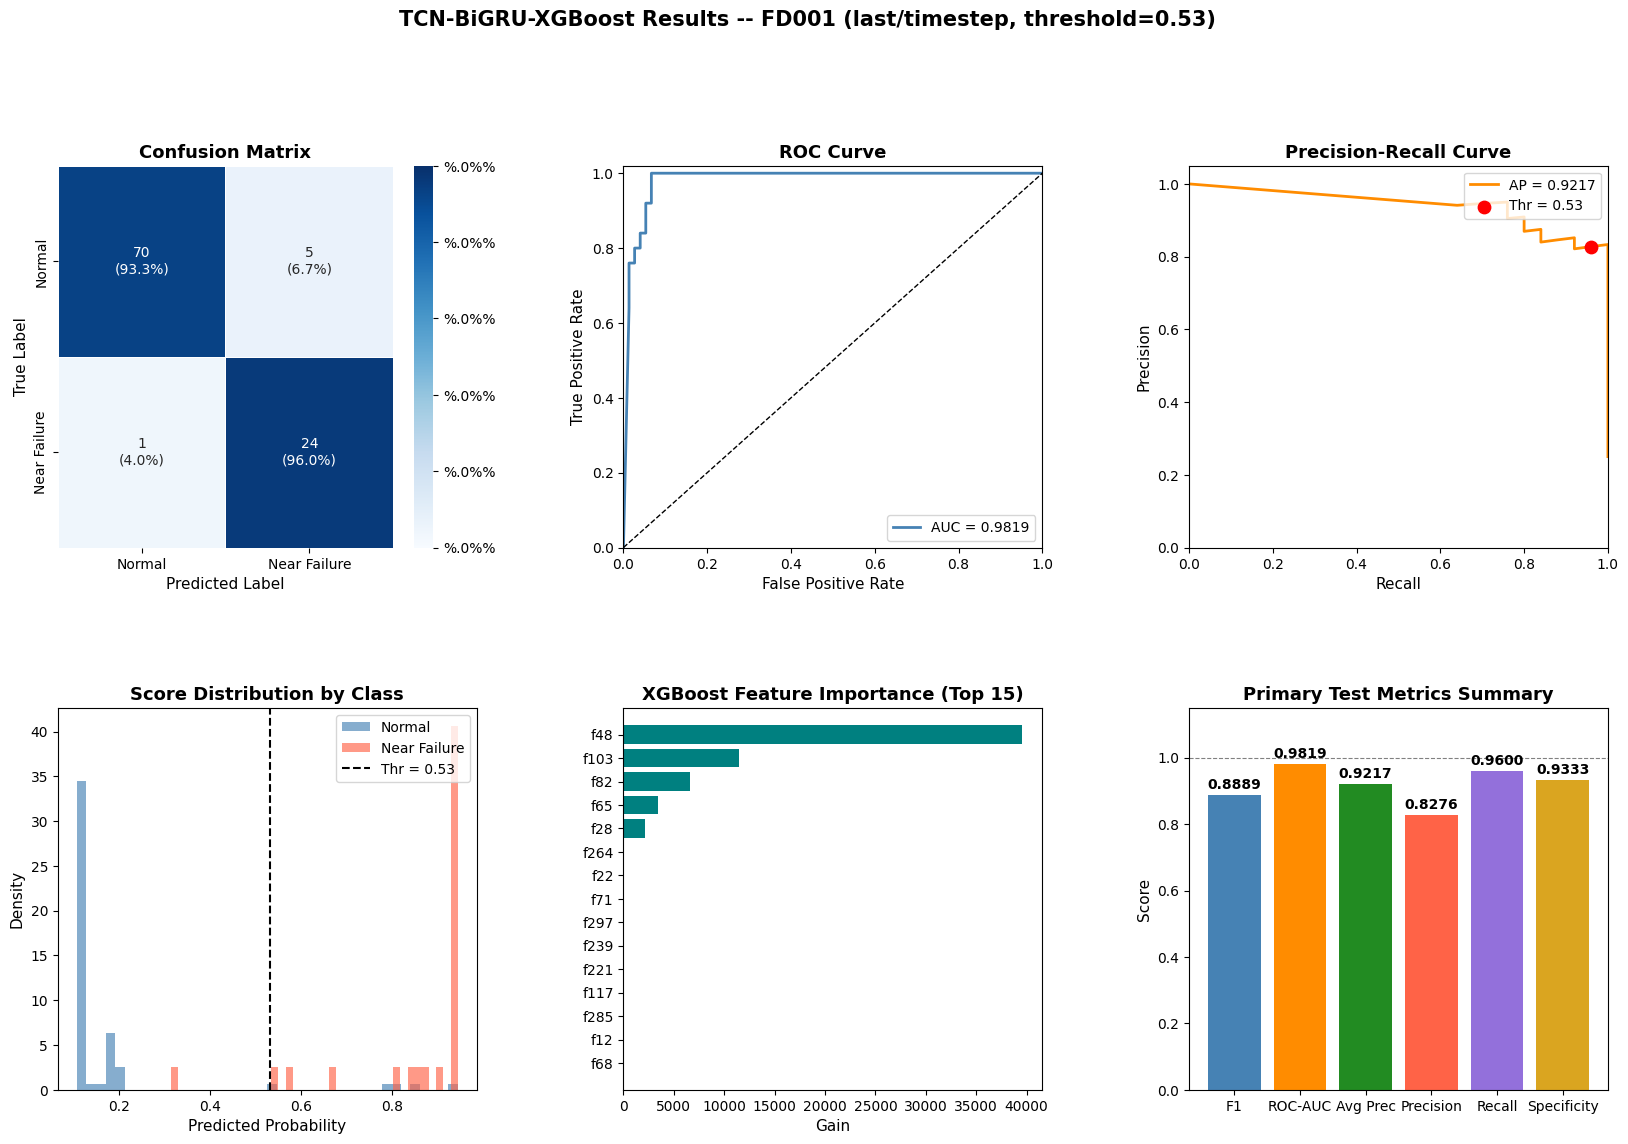

Dashboard saved: results_dashboard_FD001_last_timestep.png


In [13]:
def plot_confusion(ax, y_true, y_pred, classes=('Normal', 'Near Failure')):
    cm_raw  = confusion_matrix(y_true, y_pred, labels=[0, 1])
    row_sum = cm_raw.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm_raw.astype(float), row_sum, out=np.zeros_like(cm_raw, dtype=float), where=row_sum != 0)
    annot   = [[f'{v}\n({p:.1%})' for v, p in zip(rv, rp)]
                for rv, rp in zip(cm_raw, cm_norm)]
    sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=classes, yticklabels=classes,
                vmin=0, vmax=1, linewidths=0.5, cbar_kws={'format': '%.0%%'})
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')


def plot_roc(ax, y_true, y_score):
    if len(np.unique(y_true)) < 2:
        ax.text(0.5, 0.5, 'ROC unavailable: one class only', ha='center', va='center')
        ax.set_axis_off()
        return
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_v = roc_auc_score(y_true, y_score)
    ax.plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {auc_v:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])


def plot_pr(ax, y_true, y_score, threshold):
    if len(np.unique(y_true)) < 2:
        ax.text(0.5, 0.5, 'PR unavailable: one class only', ha='center', va='center')
        ax.set_axis_off()
        return
    prec, rec, thrs = precision_recall_curve(y_true, y_score)
    ap_v = average_precision_score(y_true, y_score)
    ax.plot(rec, prec, lw=2, color='darkorange', label=f'AP = {ap_v:.4f}')
    if len(thrs) > 0:
        idx = np.argmin(np.abs(thrs - threshold))
        ax.scatter(rec[idx], prec[idx], color='red', zorder=5, s=80,
                   label=f'Thr = {threshold:.2f}')
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])


def plot_score_dist(ax, y_true, y_score, threshold):
    for label, color, name in [(0, 'steelblue', 'Normal'),
                                (1, 'tomato', 'Near Failure')]:
        vals = y_score[y_true == label]
        if len(vals) > 0:
            ax.hist(vals, bins=40, alpha=0.65,
                    color=color, label=name, density=True)
    ax.axvline(threshold, color='black', linestyle='--', lw=1.5,
               label=f'Thr = {threshold:.2f}')
    ax.set_xlabel('Predicted Probability', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title('Score Distribution by Class', fontsize=13, fontweight='bold')
    ax.legend()


def plot_feat_importance(ax, model, top_n=15):
    scores = model.get_score(importance_type='gain')
    if not scores:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center'); return
    s_sorted = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    feats, vals = zip(*s_sorted)
    ax.barh(feats[::-1], vals[::-1], color='teal')
    ax.set_xlabel('Gain', fontsize=11)
    ax.set_title(f'XGBoost Feature Importance (Top {top_n})',
                 fontsize=13, fontweight='bold')


def plot_metrics_bar(ax, metrics_dict):
    names  = list(metrics_dict.keys())
    values = list(metrics_dict.values())
    colors = ['steelblue', 'darkorange', 'forestgreen',
              'tomato', 'mediumpurple', 'goldenrod']
    bars   = ax.bar(names, values, color=colors[:len(names)])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('Primary Test Metrics Summary', fontsize=13, fontweight='bold')
    ax.axhline(1.0, color='gray', linestyle='--', lw=0.8)


metrics_dict = {
    'F1'         : f1,
    'ROC-AUC'    : auc,
    'Avg Prec'   : ap,
    'Precision'  : precision,
    'Recall'     : recall,
    'Specificity': spec,
}

fig = plt.figure(figsize=(20, 12))
fig.suptitle(f'TCN-BiGRU-XGBoost Results -- {FD} ({primary_protocol}/{primary_decision_mode}, threshold={best_thr:.2f})',
             fontsize=15, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

plot_confusion(ax1, y_te, test_preds)
plot_roc(ax2, y_te, test_probs)
plot_pr(ax3, y_te, test_probs, best_thr)
plot_score_dist(ax4, y_te, test_probs, best_thr)
plot_feat_importance(ax5, xgb_model)
plot_metrics_bar(ax6, metrics_dict)

plt.savefig(f'results_dashboard_{FD}_{primary_protocol}_{primary_decision_mode}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Dashboard saved: results_dashboard_{FD}_{primary_protocol}_{primary_decision_mode}.png')

## Metrics Summary Table

In [14]:
report_dict = classification_report(
    y_te, test_preds, target_names=['Normal', 'Near Failure'], output_dict=True,
    zero_division=0)

rows = []
for cls in ['Normal', 'Near Failure']:
    rows.append({
        'Class'    : cls,
        'Precision': round(report_dict[cls]['precision'], 4),
        'Recall'   : round(report_dict[cls]['recall'],    4),
        'F1-Score' : round(report_dict[cls]['f1-score'],  4),
        'Support'  : int(report_dict[cls]['support']),
    })
for name, val in [('Overall F1', f1), ('ROC-AUC', auc),
                  ('Avg Precision', ap), ('Specificity', spec)]:
    rows.append({'Class': name, 'Precision': round(val, 4),
                 'Recall': '--', 'F1-Score': '--', 'Support': '--'})

df_summary = pd.DataFrame(rows).set_index('Class')

print('\n' + '=' * 72)
print(f'  {FD} -- TCN-BiGRU + XGBoost ({primary_protocol}/{primary_decision_mode})')
print('=' * 72)
print(df_summary.to_string())
print('=' * 72)

try:
    from IPython.display import display
    styled = (
        df_summary.style
        .set_caption(f'TCN-BiGRU-XGBoost Results -- {FD} ({primary_protocol}/{primary_decision_mode})')
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '14px'), ('font-weight', 'bold')]},
            {'selector': 'th',
             'props': [('background-color', '#4472C4'), ('color', 'white'),
                       ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td',
             'props': [('text-align', 'center'), ('padding', '6px 12px')]},
        ])
    )
    display(styled)
except Exception:
    pass


  FD001 -- TCN-BiGRU + XGBoost (last/timestep)
               Precision  Recall F1-Score Support
Class                                            
Normal            0.9859  0.9333   0.9589      75
Near Failure      0.8276    0.96   0.8889      25
Overall F1        0.8889      --       --      --
ROC-AUC           0.9819      --       --      --
Avg Precision     0.9217      --       --      --
Specificity       0.9333      --       --      --


,Precision,Recall,F1-Score,Support
Class,,,,
Normal,0.985900,0.933300,0.958900,75
Near Failure,0.827600,0.960000,0.888900,25
Overall F1,0.888900,--,--,--
ROC-AUC,0.981900,--,--,--
Avg Precision,0.921700,--,--,--
Specificity,0.933300,--,--,--


## Full FD001-FD004 Batch Evaluation (Engine-Sequence Protocol)

End-to-end run across all four datasets with the engine-level sequence-labeling pipeline. Each dataset reports both `last` and `sequence` test protocols. Thresholds and the timestep-vs-engine decision mode are selected on validation only; test metrics are never used to choose the reported decision mode.


In [15]:
def selected_protocol_result(protocol, y_true, probs, engine_ids, ts_thr, selected_mode,
                             engine_setting=None, allow_engine=False):
    """Return selected metrics plus per-mode diagnostics for one protocol."""
    _, _, _, pred_ts = evaluate_threshold(y_true, probs, ts_thr)
    ts_metrics = metric_dict(y_true, probs, pred_ts)

    result = {
        'selected_mode': 'timestep',
        'selected_pred': pred_ts,
        'selected_metrics': ts_metrics,
        'timestep_metrics': ts_metrics,
        'engine_metrics': None,
        'engine_setting': None,
    }

    if allow_engine and engine_setting is not None:
        e_th, e_ma, e_pw, e_mc, *_ = engine_setting
        _, _, _, pred_eng = evaluate_engine_smoothed(
            y_true, probs, engine_ids, e_th, e_ma, e_pw, e_mc)
        eng_metrics = metric_dict(y_true, probs, pred_eng)
        result['engine_metrics'] = eng_metrics
        result['engine_setting'] = f'thr={e_th:.2f},ma_k={e_ma},persist=({e_pw},{e_mc})'
        if selected_mode == 'engine':
            result['selected_mode'] = 'engine'
            result['selected_pred'] = pred_eng
            result['selected_metrics'] = eng_metrics
    return result


def run_full_pipeline(fd, cfg=CFG, seed=42):
    """End-to-end engine-sequence labeling run.

    TCN+BiGRU is trained as a masked sequence labeler, XGBoost grid search is
    train-only with engine-group CV when available, validation selects threshold
    and decision mode, and last/sequence test protocols are reported.
    """
    seed_everything(seed)

    # ---- Data ----
    train_r, test_r, rul_r = load_raw(fd)
    train_r = add_train_rul(train_r)
    test_r  = add_test_rul(test_r, rul_r)
    tr, va  = split_train_val(train_r, cfg['val_engine_frac'], seed=seed)
    fc      = get_features(tr)

    sc = StandardScaler()
    tr[fc]     = sc.fit_transform(tr[fc])
    va[fc]     = sc.transform(va[fc])
    test_r[fc] = sc.transform(test_r[fc])

    TH = cfg['rul_threshold']
    MIN_C = cfg.get('min_engine_cycles', 1)
    Xtr, ytr_seq, mask_tr_i, len_tr_i, eng_tr_grid_i, _ = make_engine_sequences(tr, fc, TH, MIN_C)
    Xva, yva_seq, mask_va_i, len_va_i, eng_va_grid_i, _ = make_engine_sequences(va, fc, TH, MIN_C)
    Xte, yte_full, mask_te_i, len_te_i, eng_te_grid_i, _ = make_engine_sequences(test_r, fc, TH, MIN_C)

    ytr = flatten_valid(ytr_seq, mask_tr_i)
    yva = flatten_valid(yva_seq, mask_va_i)
    yseq = flatten_valid(yte_full, mask_te_i)
    eng_tr_flat = flatten_valid(eng_tr_grid_i, mask_tr_i)
    eng_va_flat = flatten_valid(eng_va_grid_i, mask_va_i)
    eng_seq = flatten_valid(eng_te_grid_i, mask_te_i)
    last_idx = last_valid_flat_indices(mask_te_i)
    ylast = yseq[last_idx]
    eng_last = eng_seq[last_idx]

    # ---- Train TCN+BiGRU with masked hybrid loss ----
    m  = TCNBiGRU(Xtr.shape[2], cfg).to(DEVICE)
    raw_pr = float((ytr == 0).sum() / max((ytr == 1).sum(), 1))
    pw = torch.tensor([raw_pr * cfg['pos_weight_boost']], dtype=torch.float32).to(DEVICE)
    crit_cls   = FocalLoss(gamma=cfg['focal_gamma'], pos_weight=pw)
    crit_recon = nn.MSELoss(reduction='none')
    Rw = cfg['recon_weight']

    opt = torch.optim.AdamW(m.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg['epochs'], eta_min=1e-5)
    trl = get_loader(Xtr, ytr_seq, mask_tr_i, len_tr_i, cfg['batch_size'])
    vll = get_loader(Xva, yva_seq, mask_va_i, len_va_i, cfg['batch_size'], shuffle=False)
    beta = cfg['recall_beta']

    best_fb, best_st, no_imp = -1.0, None, 0
    for ep in range(1, cfg['epochs'] + 1):
        m.train()
        for xb, yb, mb, lb in trl:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            mb = mb.to(DEVICE).bool()
            lb = lb.to(DEVICE)
            logits, recon, _ = m(xb, lb)
            cls_loss = crit_cls(logits, yb, mb)
            recon_loss = crit_recon(recon, xb).mean(dim=2)[mb].mean()
            loss = cls_loss + Rw * recon_loss
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
        sch.step()
        m.eval(); vp_enc, vt = [], []
        with torch.no_grad():
            for xb, yb, mb, lb in vll:
                logits, _, _ = m(xb.to(DEVICE), lb.to(DEVICE))
                mb = mb.to(DEVICE).bool()
                vp_enc.extend(torch.sigmoid(logits)[mb].cpu().numpy())
                vt.extend(yb.to(DEVICE)[mb].cpu().numpy())
        vfb = fbeta_score(vt, (np.array(vp_enc) >= 0.5).astype(int), beta=beta, zero_division=0)
        if vfb > best_fb:
            best_fb = vfb
            best_st = {k: v.cpu().clone() for k, v in m.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if no_imp >= cfg['patience']:
            break
    m.load_state_dict(best_st)

    # ---- Embedding extraction ----
    @torch.no_grad()
    def _emb_seq(X, lengths):
        m.eval(); parts = []
        ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(lengths))
        for xb, lb in DataLoader(ds, batch_size=64, shuffle=False):
            parts.append(m.embed(xb.to(DEVICE), lb.to(DEVICE)).cpu().numpy())
        return np.concatenate(parts, axis=0)

    e_tr_seq = _emb_seq(Xtr, len_tr_i)
    e_va_seq = _emb_seq(Xva, len_va_i)
    e_te_seq = _emb_seq(Xte, len_te_i)
    e_tr = e_tr_seq[mask_tr_i]
    e_va = e_va_seq[mask_va_i]
    e_seq = e_te_seq[mask_te_i]
    e_last = e_seq[last_idx]

    if cfg['use_semantic_features']:
        s_tr = extract_prefix_semantic_features(Xtr, mask_tr_i)
        s_va = extract_prefix_semantic_features(Xva, mask_va_i)
        s_seq = extract_prefix_semantic_features(Xte, mask_te_i)
        s_last = s_seq[last_idx]
        f_tr = np.concatenate([e_tr, s_tr], axis=1)
        f_va = np.concatenate([e_va, s_va], axis=1)
        f_last = np.concatenate([e_last, s_last], axis=1)
        f_seq = np.concatenate([e_seq, s_seq], axis=1)
    else:
        f_tr, f_va, f_last, f_seq = e_tr, e_va, e_last, e_seq

    # ---- GridSearchCV on TRAIN ONLY ----
    sp     = float((ytr == 0).sum() / max((ytr == 1).sum(), 1))
    sp_bst = sp * cfg['pos_weight_boost']
    f_beta = make_scorer(fbeta_score, beta=beta, zero_division=0)
    if StratifiedGroupKFold is not None and len(np.unique(eng_tr_flat)) >= cfg['grid_cv_folds']:
        cv = StratifiedGroupKFold(cfg['grid_cv_folds'], shuffle=True, random_state=seed)
        fit_kwargs = {'groups': eng_tr_flat}
    else:
        cv = StratifiedKFold(cfg['grid_cv_folds'], shuffle=True, random_state=seed)
        fit_kwargs = {}

    gs = GridSearchCV(
        XGBClassifier(objective='binary:logistic', n_estimators=400,
                      scale_pos_weight=sp_bst, tree_method='hist',
                      eval_metric='logloss', random_state=seed, verbosity=0),
        param_grid={
            'max_depth'        : [4, 6],
            'learning_rate'    : [0.03, 0.1],
            'min_child_weight' : [1, 3],
            'subsample'        : [0.8, 1.0],
            'colsample_bytree' : [0.8, 1.0],
        },
        scoring=f_beta,
        cv=cv,
        n_jobs=cfg['grid_n_jobs'], verbose=0,
    )
    gs.fit(f_tr, ytr, **fit_kwargs)
    bp = gs.best_params_

    # ---- Final XGBoost (train only, val for early stopping) ----
    xm = xgb.train(
        {'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'],
         'eta': bp['learning_rate'], 'max_depth': bp['max_depth'],
         'subsample': bp['subsample'], 'colsample_bytree': bp['colsample_bytree'],
         'min_child_weight': bp['min_child_weight'],
         'reg_alpha': cfg['xgb_alpha'], 'reg_lambda': cfg['xgb_lambda'],
         'scale_pos_weight': sp_bst, 'tree_method': 'hist', 'seed': seed},
        xgb.DMatrix(f_tr, label=ytr),
        num_boost_round=cfg['xgb_rounds'],
        evals=[(xgb.DMatrix(f_va, label=yva), 'val')],
        early_stopping_rounds=cfg['xgb_es_rounds'],
        verbose_eval=False,
    )

    # ---- Threshold + decision-mode selection on VAL ----
    vp = xm.predict(xgb.DMatrix(f_va))
    ts_thr, ts_p_v, ts_r_v, ts_f1_v = choose_timestep_threshold(
        yva, vp, min_prec=cfg['min_precision'], f1_tol=cfg['f1_tolerance'])

    engine_setting = None
    engine_val = None
    if cfg['use_engine_smoothing']:
        engine_setting = choose_engine_setting(
            yva, vp, eng_va_flat,
            min_prec=cfg['min_precision'], f1_tol=cfg['f1_tolerance'], cfg=cfg)
        e_th, e_ma, e_pw, e_mc, e_p_v, e_r_v, e_f1_v = engine_setting
        engine_val = {'mode': 'engine', 'f1': e_f1_v, 'recall': e_r_v, 'precision': e_p_v}

    val_modes = [{'mode': 'timestep', 'f1': ts_f1_v, 'recall': ts_r_v, 'precision': ts_p_v}]
    if engine_val is not None:
        val_modes.append(engine_val)
    selected_mode = sorted(
        val_modes,
        key=lambda c: (-c['f1'], -c['recall'], 0 if c['mode'] == 'timestep' else 1)
    )[0]['mode']

    # ---- Dual-protocol test reporting ----
    p_last = xm.predict(xgb.DMatrix(f_last))
    p_seq  = xm.predict(xgb.DMatrix(f_seq))

    last_res = selected_protocol_result(
        'last', ylast, p_last, eng_last, ts_thr, selected_mode,
        engine_setting=None, allow_engine=False)
    seq_res = selected_protocol_result(
        'sequence', yseq, p_seq, eng_seq, ts_thr, selected_mode,
        engine_setting=engine_setting, allow_engine=cfg['use_engine_smoothing'])

    out = {
        'Val Decision': selected_mode,
        'Val Timestep F1': float(ts_f1_v),
        'Val Engine F1': float(engine_val['f1']) if engine_val is not None else float('nan'),
        'Last Decision': last_res['selected_mode'],
        'Last F1': float(last_res['selected_metrics']['F1']),
        'Last Precision': float(last_res['selected_metrics']['Precision']),
        'Last Recall': float(last_res['selected_metrics']['Recall']),
        'Last Specificity': float(last_res['selected_metrics']['Specificity']),
        'Last AUC': float(last_res['selected_metrics']['AUC']),
        'Last Avg Prec': float(last_res['selected_metrics']['Avg Prec']),
        'Sequence Decision': seq_res['selected_mode'],
        'Sequence F1': float(seq_res['selected_metrics']['F1']),
        'Sequence Precision': float(seq_res['selected_metrics']['Precision']),
        'Sequence Recall': float(seq_res['selected_metrics']['Recall']),
        'Sequence Specificity': float(seq_res['selected_metrics']['Specificity']),
        'Sequence AUC': float(seq_res['selected_metrics']['AUC']),
        'Sequence Avg Prec': float(seq_res['selected_metrics']['Avg Prec']),
        'Sequence Timestep F1': float(seq_res['timestep_metrics']['F1']),
        'Sequence Engine F1': float(seq_res['engine_metrics']['F1']) if seq_res['engine_metrics'] is not None else float('nan'),
        'Engine Setting': seq_res['engine_setting'],
        'Best Params': str(bp),
    }
    return out


print('Running all CMAPSS datasets with engine-level sequence-labeling pipeline...')
all_results = {}
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    print(f'\n--- {fd} ---', flush=True)
    r = run_full_pipeline(fd, seed=42)
    all_results[fd] = r
    print(f"  last     [{r['Last Decision']}] F1={r['Last F1']:.4f}  "
          f"P={r['Last Precision']:.4f}  R={r['Last Recall']:.4f}  AUC={r['Last AUC']:.4f}")
    print(f"  sequence [{r['Sequence Decision']}] F1={r['Sequence F1']:.4f}  "
          f"P={r['Sequence Precision']:.4f}  R={r['Sequence Recall']:.4f}  AUC={r['Sequence AUC']:.4f}")
    print(f"  VAL decision={r['Val Decision']} | VAL timestep F1={r['Val Timestep F1']:.4f} | "
          f"VAL engine F1={r['Val Engine F1']:.4f}")


Running all CMAPSS datasets with engine-level sequence-labeling pipeline...

--- FD001 ---
  last     [timestep] F1=0.8980  P=0.9167  R=0.8800  AUC=0.9843
  sequence [timestep] F1=0.8463  P=0.7686  R=0.9414  AUC=0.9945
  VAL decision=timestep | VAL timestep F1=0.9867 | VAL engine F1=0.9856

--- FD002 ---
  last     [timestep] F1=0.3762  P=0.2317  R=1.0000  AUC=0.6910
  sequence [timestep] F1=0.2439  P=0.1389  R=1.0000  AUC=0.9073
  VAL decision=timestep | VAL timestep F1=1.0000 | VAL engine F1=1.0000

--- FD003 ---
  last     [timestep] F1=0.5882  P=0.4167  R=1.0000  AUC=0.9894
  sequence [engine] F1=0.7003  P=0.5388  R=1.0000  AUC=0.9988
  VAL decision=engine | VAL timestep F1=0.9845 | VAL engine F1=0.9867

--- FD004 ---
  last     [timestep] F1=0.3467  P=0.2097  R=1.0000  AUC=0.5000
  sequence [timestep] F1=0.2023  P=0.1125  R=1.0000  AUC=0.9235
  VAL decision=timestep | VAL timestep F1=1.0000 | VAL engine F1=1.0000


## Cross-Dataset Engine-Sequence Results Table


  TCN-BiGRU + XGBoost -- Cross-Dataset Engine-Sequence Results
      Val Decision Last Decision Sequence Decision  Last F1  Sequence F1  Last AUC  Sequence AUC  Last Precision  Sequence Precision  Last Recall  Sequence Recall  Sequence Timestep F1  Sequence Engine F1                 Engine Setting
FD001     timestep      timestep          timestep   0.8980       0.8463    0.9843        0.9945          0.9167              0.7686         0.88           0.9414                0.8463              0.8509  thr=0.23,ma_k=3,persist=(2,1)
FD002     timestep      timestep          timestep   0.3762       0.2439    0.6910        0.9073          0.2317              0.1389         1.00           1.0000                0.2439              0.2421  thr=0.26,ma_k=7,persist=(2,1)
FD003       engine      timestep            engine   0.5882       0.7003    0.9894        0.9988          0.4167              0.5388         1.00           1.0000                0.7012              0.7003  thr=0.15,ma_k=5,persist

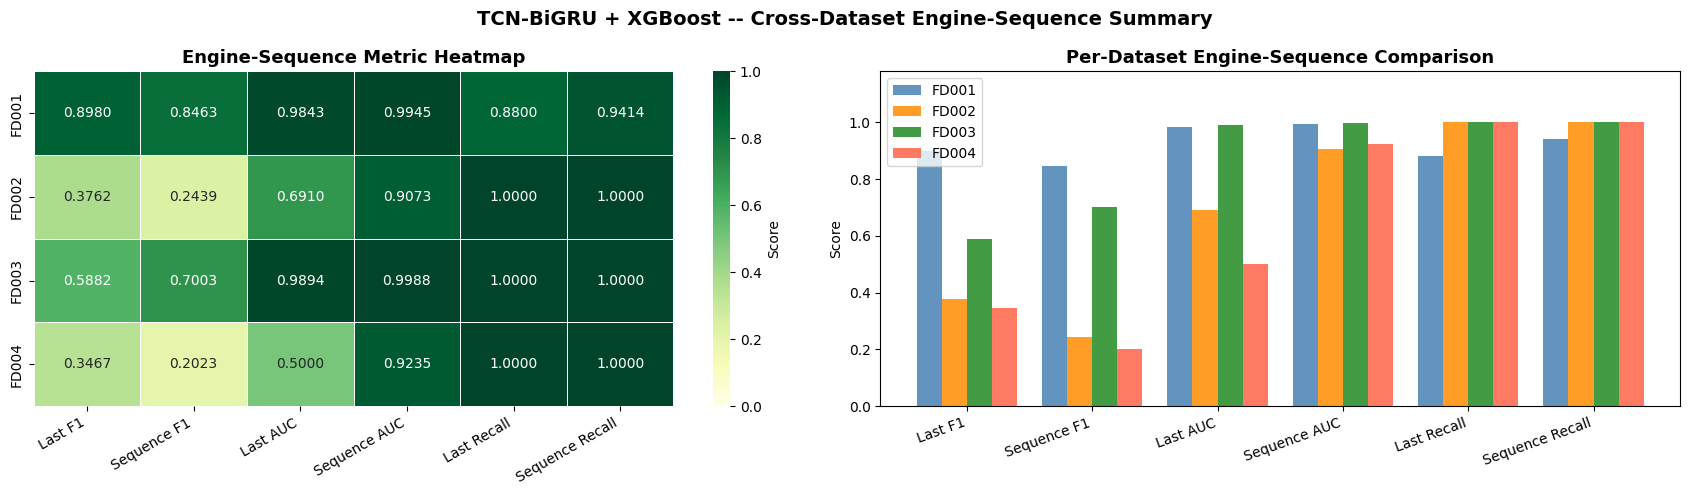

Saved: cross_dataset_engine_sequence_results.png


,Val Decision,Last Decision,Sequence Decision,Last F1,Sequence F1,Last AUC,Sequence AUC,Last Precision,Sequence Precision,Last Recall,Sequence Recall,Sequence Timestep F1,Sequence Engine F1,Engine Setting
FD001,timestep,timestep,timestep,0.898000,0.846300,0.984300,0.994500,0.916700,0.768600,0.880000,0.941400,0.846300,0.850900,"thr=0.23,ma_k=3,persist=(2,1)"
FD002,timestep,timestep,timestep,0.376200,0.243900,0.691000,0.907300,0.231700,0.138900,1.000000,1.000000,0.243900,0.242100,"thr=0.26,ma_k=7,persist=(2,1)"
FD003,engine,timestep,engine,0.588200,0.700300,0.989400,0.998800,0.416700,0.538800,1.000000,1.000000,0.701200,0.700300,"thr=0.15,ma_k=5,persist=(2,1)"
FD004,timestep,timestep,timestep,0.346700,0.202300,0.500000,0.923500,0.209700,0.112500,1.000000,1.000000,0.202300,0.202400,"thr=0.10,ma_k=5,persist=(2,1)"


In [16]:
result_rows = pd.DataFrame(all_results).T
numeric_cols = [
    'Val Timestep F1', 'Val Engine F1',
    'Last F1', 'Last AUC', 'Last Avg Prec', 'Last Precision', 'Last Recall', 'Last Specificity',
    'Sequence F1', 'Sequence AUC', 'Sequence Avg Prec', 'Sequence Precision', 'Sequence Recall', 'Sequence Specificity',
    'Sequence Timestep F1', 'Sequence Engine F1',
]

for col in numeric_cols:
    result_rows[col] = pd.to_numeric(result_rows[col], errors='coerce')

summary_numeric = result_rows[numeric_cols].copy()
summary_numeric.loc['Mean'] = summary_numeric.mean(numeric_only=True)
summary_numeric.loc['Std']  = summary_numeric.iloc[:-1].std(numeric_only=True)

report_cols = [
    'Val Decision', 'Last Decision', 'Sequence Decision',
    'Last F1', 'Sequence F1', 'Last AUC', 'Sequence AUC',
    'Last Precision', 'Sequence Precision', 'Last Recall', 'Sequence Recall',
    'Sequence Timestep F1', 'Sequence Engine F1', 'Engine Setting',
]

print('=' * 110)
print('  TCN-BiGRU + XGBoost -- Cross-Dataset Engine-Sequence Results')
print('=' * 110)
print(result_rows[report_cols].round(4).to_string())
print('=' * 110)
print('\nNumeric mean/std:')
print(summary_numeric.round(4).to_string())
print('=' * 110)

# Heatmap + grouped bar chart for headline protocol metrics
headline_cols = ['Last F1', 'Sequence F1', 'Last AUC', 'Sequence AUC', 'Last Recall', 'Sequence Recall']
fig, (ax_heat, ax_bar) = plt.subplots(1, 2, figsize=(17, 5))

heat_data = result_rows.loc[['FD001', 'FD002', 'FD003', 'FD004'], headline_cols]
sns.heatmap(heat_data.astype(float), annot=True, fmt='.4f', cmap='YlGn',
            vmin=0, vmax=1, ax=ax_heat, linewidths=0.5,
            cbar_kws={'label': 'Score'})
ax_heat.set_title('Engine-Sequence Metric Heatmap', fontsize=13, fontweight='bold')
ax_heat.set_xticklabels(headline_cols, rotation=30, ha='right')

x      = np.arange(len(headline_cols))
w      = 0.2
fds    = ['FD001', 'FD002', 'FD003', 'FD004']
colors = ['steelblue', 'darkorange', 'forestgreen', 'tomato']
for i, (fd_name, col) in enumerate(zip(fds, colors)):
    vals = result_rows.loc[fd_name, headline_cols].values.astype(float)
    ax_bar.bar(x + i * w, vals, width=w, label=fd_name, color=col, alpha=0.85)
ax_bar.set_xticks(x + 1.5 * w)
ax_bar.set_xticklabels(headline_cols, rotation=20, ha='right')
ax_bar.set_ylim(0, 1.18)
ax_bar.set_ylabel('Score')
ax_bar.set_title('Per-Dataset Engine-Sequence Comparison', fontsize=13, fontweight='bold')
ax_bar.legend()

plt.suptitle('TCN-BiGRU + XGBoost -- Cross-Dataset Engine-Sequence Summary',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cross_dataset_engine_sequence_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cross_dataset_engine_sequence_results.png')

try:
    from IPython.display import display
    styled = (
        result_rows[report_cols].round(4).style
        .set_caption('TCN-BiGRU + XGBoost -- Engine-Sequence Cross-Dataset Results')
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '8px')]},
            {'selector': 'th',
             'props': [('background-color', '#4472C4'), ('color', 'white'),
                       ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td',
             'props': [('text-align', 'center'), ('padding', '6px 14px')]},
        ])
        .highlight_max(subset=['Last F1', 'Sequence F1', 'Last AUC', 'Sequence AUC'], axis=0,
                       props='font-weight: bold; border: 2px solid #2F75B6;')
    )
    display(styled)
except Exception:
    pass


## Optional Article Experiments: Ablation and Multi-Seed Checks

These cells are intentionally opt-in because each row retrains the full pipeline. Use them before writing final paper tables, not during every notebook run.

In [17]:
def cfg_variant(**updates):
    cfg = dict(CFG)
    cfg.update(updates)
    return cfg


def run_ablation_suite(fd=None, seed=42):
    """Full retraining ablation table for article claims.

    Recommended minimum rows:
    - baseline deep-only with focal sequence-labeling loss
    - + hybrid reconstruction loss
    - + semantic fusion
    - + engine smoothing / business threshold as the final model
    """
    fd = fd or CFG.get('ablation_fd', CFG['dataset'])
    variants = [
        ('baseline_deep_only', cfg_variant(recon_weight=0.0, use_semantic_features=False, use_engine_smoothing=False)),
        ('+hybrid_loss',       cfg_variant(recon_weight=CFG['recon_weight'], use_semantic_features=False, use_engine_smoothing=False)),
        ('+semantic_fusion',   cfg_variant(recon_weight=CFG['recon_weight'], use_semantic_features=True,  use_engine_smoothing=False)),
        ('+engine_smoothing',  cfg_variant(recon_weight=CFG['recon_weight'], use_semantic_features=True,  use_engine_smoothing=True)),
    ]

    rows = []
    for name, cfg in variants:
        print(f'\nAblation: {name} ({fd}, seed={seed})')
        res = run_full_pipeline(fd, cfg=cfg, seed=seed)
        rows.append({
            'Variant': name,
            'FD': fd,
            'Seed': seed,
            'Last F1': res['Last F1'],
            'Sequence F1': res['Sequence F1'],
            'Sequence Decision': res['Sequence Decision'],
            'Last AUC': res['Last AUC'],
            'Sequence AUC': res['Sequence AUC'],
            'Last Recall': res['Last Recall'],
            'Sequence Recall': res['Sequence Recall'],
        })
    return pd.DataFrame(rows)


def run_recon_weight_grid(fd=None, values=None, seed=42):
    """Validation-first grid for recon_weight.

    Select recon_weight by Val Selected F1, then treat the corresponding test
    scores as the locked final evaluation for that chosen configuration.
    """
    fd = fd or CFG.get('ablation_fd', CFG['dataset'])
    values = values or CFG.get('recon_weight_grid', [0.0, 0.1, 0.3, 0.5, 1.0])

    rows = []
    for rw in values:
        print(f'\nrecon_weight grid: {fd}, recon_weight={rw}, seed={seed}')
        cfg = cfg_variant(recon_weight=float(rw))
        res = run_full_pipeline(fd, cfg=cfg, seed=seed)
        val_selected_f1 = res['Val Engine F1'] if res['Val Decision'] == 'engine' else res['Val Timestep F1']
        rows.append({
            'recon_weight': float(rw),
            'Val Decision': res['Val Decision'],
            'Val Selected F1': val_selected_f1,
            'Val Timestep F1': res['Val Timestep F1'],
            'Val Engine F1': res['Val Engine F1'],
            'Last F1': res['Last F1'],
            'Sequence F1': res['Sequence F1'],
            'Last AUC': res['Last AUC'],
            'Sequence AUC': res['Sequence AUC'],
        })
    df_grid = pd.DataFrame(rows).sort_values(
        ['Val Selected F1', 'recon_weight'], ascending=[False, True]
    ).reset_index(drop=True)
    return df_grid


def run_multiseed_summary(fd=None, seeds=None, cfg=None):
    """Retrain the final configuration across seeds and report mean/std."""
    fd = fd or CFG['dataset']
    seeds = seeds or CFG.get('seed_list', [42, 123, 2024])
    cfg = cfg or CFG

    rows = []
    for seed in seeds:
        print(f'\nMulti-seed run: {fd}, seed={seed}')
        res = run_full_pipeline(fd, cfg=cfg, seed=seed)
        rows.append({
            'Seed': seed,
            'Last F1': res['Last F1'],
            'Sequence F1': res['Sequence F1'],
            'Last AUC': res['Last AUC'],
            'Sequence AUC': res['Sequence AUC'],
            'Last Recall': res['Last Recall'],
            'Sequence Recall': res['Sequence Recall'],
        })
    df_seed = pd.DataFrame(rows).set_index('Seed')
    return pd.concat({'runs': df_seed, 'mean': df_seed.mean().to_frame().T, 'std': df_seed.std().to_frame().T})


if CFG.get('ablation_enabled', False):
    df_ablation = run_ablation_suite()
    print(df_ablation.round(4).to_string(index=False))
    try:
        from IPython.display import display
        display(df_ablation.round(4))
    except Exception:
        pass
else:
    print('Ablation/multi-seed helpers loaded. Set CFG["ablation_enabled"] = True or call run_recon_weight_grid()/run_ablation_suite()/run_multiseed_summary() manually.')


Ablation/multi-seed helpers loaded. Set CFG["ablation_enabled"] = True or call run_recon_weight_grid()/run_ablation_suite()/run_multiseed_summary() manually.


## Model Saving

In [18]:
SAVE_DIR = '/content/drive/MyDrive/models'
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model.state_dict(), f'{SAVE_DIR}/tcn_bigru_sequence_{FD}.pt')
xgb_model.save_model(f'{SAVE_DIR}/xgb_sequence_{FD}.ubj')

print(f'Models saved to {SAVE_DIR}/')
print(f'  tcn_bigru_sequence_{FD}.pt')
print(f'  xgb_sequence_{FD}.ubj')


Models saved to /content/drive/MyDrive/models/
  tcn_bigru_sequence_FD001.pt
  xgb_sequence_FD001.ubj
